# Part 1c: Early Stopping — TensorFlow & PyTorch

**Objective:** Demonstrate early stopping as a regularization technique. Training is halted when validation loss stops improving, preventing overfitting.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy
print(f"TF: {tf.__version__}, PyTorch: {torch.__version__}")

TF: 2.19.0, PyTorch: 2.10.0+cu128


In [2]:
# Data
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32") / 255.0, X_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## TensorFlow: Early Stopping with Keras Callback
Keras provides `EarlyStopping` callback. Key parameters:
- `monitor`: metric to watch (val_loss)
- `patience`: epochs to wait for improvement
- `restore_best_weights`: roll back to the best epoch's weights

In [3]:
# TF model without early stopping (overfit baseline)
def build_model():
    return keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

model_no_es = build_model()
model_no_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("--- Training WITHOUT Early Stopping (100 epochs) ---")
hist_no_es = model_no_es.fit(X_train_flat, y_train, epochs=100, batch_size=256,
                              validation_split=0.2, verbose=0)
print(f"Final val_acc: {hist_no_es.history['val_accuracy'][-1]:.4f}")

--- Training WITHOUT Early Stopping (100 epochs) ---
Final val_acc: 0.4925


In [4]:
# TF model WITH early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,               # wait 5 epochs with no improvement
    restore_best_weights=True, # go back to the best weights
    verbose=1
)

model_es = build_model()
model_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("--- Training WITH Early Stopping (max 100 epochs) ---")
hist_es = model_es.fit(X_train_flat, y_train, epochs=100, batch_size=256,
                        validation_split=0.2, callbacks=[early_stop], verbose=0)
print(f"Stopped at epoch {len(hist_es.history['val_loss'])}")
print(f"Best val_acc: {max(hist_es.history['val_accuracy']):.4f}")

--- Training WITH Early Stopping (max 100 epochs) ---
Epoch 23: early stopping
Restoring model weights from the end of the best epoch: 18.
Stopped at epoch 23
Best val_acc: 0.5109


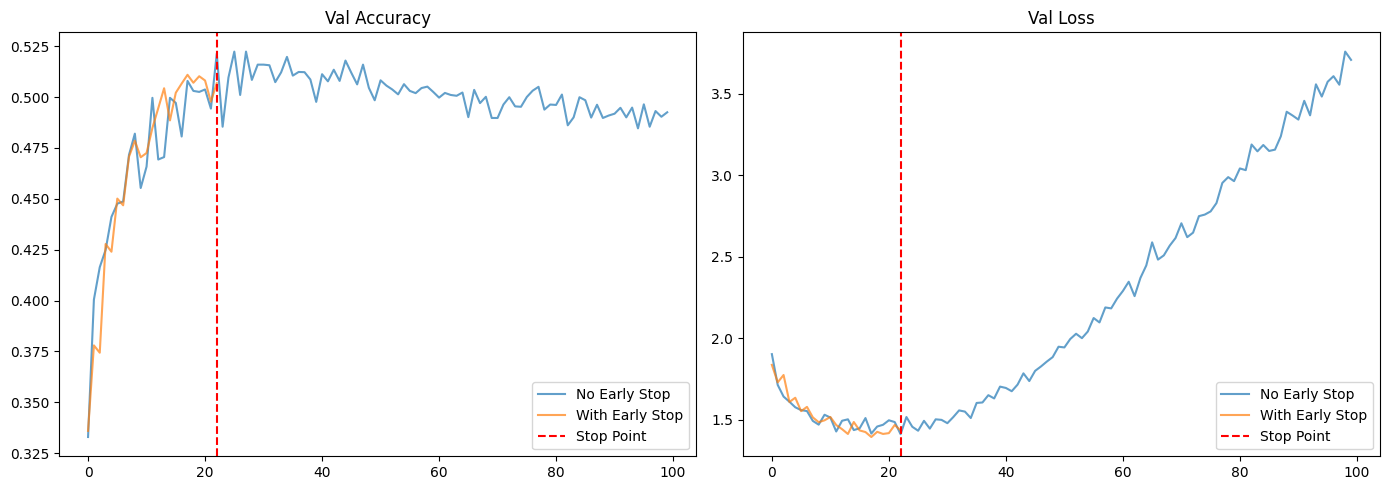

In [5]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_no_es.history['val_accuracy'], label='No Early Stop', alpha=0.7)
axes[0].plot(hist_es.history['val_accuracy'], label='With Early Stop', alpha=0.7)
axes[0].axvline(len(hist_es.history['val_accuracy'])-1, color='red', linestyle='--', label='Stop Point')
axes[0].set_title('Val Accuracy'); axes[0].legend()

axes[1].plot(hist_no_es.history['val_loss'], label='No Early Stop', alpha=0.7)
axes[1].plot(hist_es.history['val_loss'], label='With Early Stop', alpha=0.7)
axes[1].axvline(len(hist_es.history['val_loss'])-1, color='red', linestyle='--', label='Stop Point')
axes[1].set_title('Val Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Manual Early Stopping
PyTorch doesn't have built-in early stopping, so we implement it ourselves.

=== PyTorch with Early Stopping ===
Epoch 20: val_loss=1.4276, val_acc=0.5059
Early stopping at epoch 21 (patience=5)


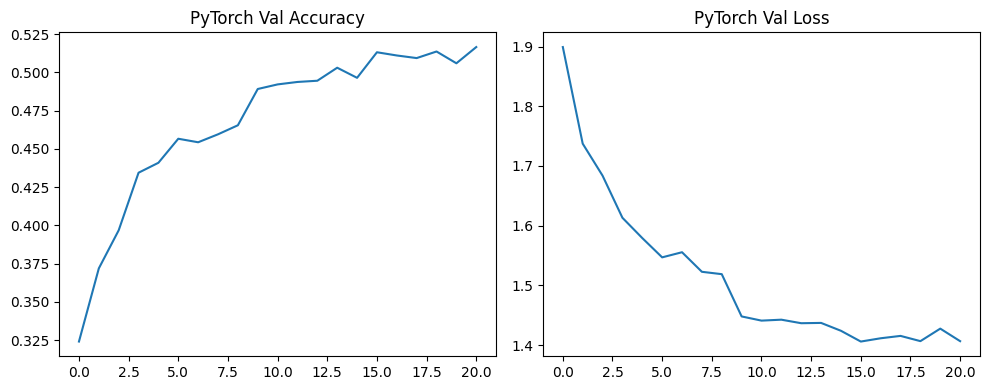

In [6]:
# PyTorch early stopping implementation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_flat[:40000]),
                                         torch.LongTensor(y_train[:40000])), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_flat[40000:]),
                                       torch.LongTensor(y_train[40000:])), batch_size=256)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_flat),
                                        torch.LongTensor(y_test)), batch_size=256)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3072, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10))
    def forward(self, x): return self.net(x)

def train_with_early_stopping(model, patience=5, max_epochs=100):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(max_epochs):
        # Train
        model.train()
        train_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
            train_loss += loss.item()
        history['train_loss'].append(train_loss / len(train_loader))

        # Validate
        model.eval()
        val_loss = correct = total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += crit(out, yb).item()
                correct += (out.argmax(1) == yb).sum().item()
                total += yb.size(0)
        val_loss /= len(val_loader)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(correct / total)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (patience={patience})")
                model.load_state_dict(best_weights)  # restore best weights
                break

        if (epoch+1) % 20 == 0:
            print(f"Epoch {epoch+1}: val_loss={val_loss:.4f}, val_acc={history['val_acc'][-1]:.4f}")
    return history

print("=== PyTorch with Early Stopping ===")
pt_model = SimpleNet()
pt_hist = train_with_early_stopping(pt_model, patience=5, max_epochs=100)

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1); plt.plot(pt_hist['val_acc']); plt.title('PyTorch Val Accuracy')
plt.subplot(1,2,2); plt.plot(pt_hist['val_loss']); plt.title('PyTorch Val Loss')
plt.tight_layout(); plt.show()

## Key Takeaways
- Early stopping monitors validation loss and halts training when it stops improving
- `patience` controls how many epochs to wait — too low = premature stop, too high = overfitting
- `restore_best_weights=True` (TF) or manual deepcopy (PyTorch) ensures we use the best model
- Early stopping is **free** — no extra hyperparameters to tune besides patience
- Works well combined with other regularization techniques (dropout, L2, etc.)